# 「大庆市区应届 Q-Q 曲线」（红线）是怎么来的？

《绥化一中高三三班中考和高考分位数对应图》里那条红线，回答的是一个问题：

> **一个人在 2004 年大庆市区中考考了 z 分，三年后 2007 年高考大约会考多少分？**

做法叫「分位数对应」(Q-Q)：不看具体的人，只看**名次**——「中考排大庆市区第 n 名」≈「高考排全省第 m 名」，再查一分一段表把 m 换成高考分。
整条链有三步：

$$ \text{中考分 } z \;\xrightarrow{\text{①}}\; \text{大庆市区位次 } n \;\xrightarrow{\text{②}}\; \text{全省理科位次 } m \;\xrightarrow{\text{③}}\; \text{高考分 } g $$

- ① 数录取总表里比这个分高的人；
- ② 用若干「锚点」把市区应届位次 n 对到全省位次 m，锚点之间按**对数**插值；
- ③ 查 2007 年理科一分一段表。

难点在②：大庆高考高分段里有大量**外县生**和**复读生**，他们不在 2004 年大庆市区的中考名次里，所以锚点里的人数必须只数「市区应届」。
这个 notebook 把三步都重新算一遍，并和页面使用的校正 CSV 逐行对照。

## 0 读数据

In [1]:
import math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Hiragino Sans GB', 'Heiti TC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def find(name):   # 在 content/kao 里运行，或从仓库根目录运行均可
    return next(p for p in [Path(name), Path('content/kao')/name] if p.exists())
rd = lambda name: pd.read_csv(find(name), encoding='utf-8-sig')

roster = rd('2004年大庆中考录取总表.csv')            # 5760 人逐人成绩
roster['文体'] = pd.to_numeric(roster['文化课+体育成绩'])   # 中考文体总分（文化 + 体育）
ys = rd('2007年高考理科一分一段表.csv')              # 2007 黑龙江理科：分数 → 累计人数
shiyan = rd('2007年大庆实验中学高考高分段人数统计.csv')   # 大庆全市（含四县）理科高分段人数
page = rd('2004年中考和2007年高考大庆市区（市区应届校正）.csv')   # 页面使用的校正 CSV：用来核对
page.columns = ['z', 'n', 'm', 'g', 'm_old', 'g_old', 'diff', 'note']
old = rd('2004年中考和2007年高考大庆市区.csv')       # 旧（未校正）曲线：只用来对比
print(len(roster), '名考生；一分一段', ys['分数'].min(), '–', ys['分数'].max(), '分')

5760 名考生；一分一段 150 – 718 分


## 1 第①步：中考分 → 大庆市区位次 n

录取总表给出每人的「文化课 + 体育」总分。分数 z 的「市区位次」取**比 z 高的人数 + 1**
（也就是考 z 分的人里**最靠前**可能是第几名；没人考的分数取下一个有人的名次）。

In [2]:
def city_rank(z):
    return int((roster['文体'] > z).sum() + 1)

zs = page['z'].to_numpy()
mine = np.array([city_rank(z) for z in zs])
ok = (mine == page['n'].to_numpy())
print(f'与页面 CSV 的「大庆市区位次」逐行对比：{ok.sum()} / {len(zs)} 行一致（{zs.min()}–{zs.max()} 分）')
pd.DataFrame({'中考': zs[:8], '本 notebook 算出的位次': mine[:8], '页面 CSV': page['n'][:8]}).set_index('中考').T

与页面 CSV 的「大庆市区位次」逐行对比：61 / 61 行一致（600–660 分）


中考,660,659,658,657,656,655,654,653
本 notebook 算出的位次,2,2,2,2,3,4,5,7
页面 CSV,2,2,2,2,3,4,5,7


## 2 第②步：位次 n → 全省位次 m（锚点）

这一步的想法：**大庆市区应届生里高考 ≥ g 分的有 n(g) 人；这 n(g) 个人在全省理科里的位次，就是「≥ g 分」的全省累计人数 m(g)**
（查一分一段表）。每个 g 给出一个锚点 (n(g), m(g))；我们把「中考市区第 n 名」和「高考全省第 m 名」配成一对。

- **m(g)**：直接查 2007 年一分一段表的累计人数。
- **n(g)**：只数「市区应届」，不能直接用大庆全市的人数——下面解释。

In [3]:
cum = dict(zip(ys['分数'], ys['累计人数']))
m_of = lambda g: cum[g]

# 大庆全市（含四县）理科高分段人数
city_all = (shiyan[shiyan['科类'] == '理科'].assign(g=lambda d: d['分数段'].str.extract(r'(\d+)')[0].astype(int))
            .set_index('g')['全市人数(含四县)'])
pd.DataFrame({'大庆全市(含四县) ≥g': city_all.loc[[690, 680, 675, 670, 665, 660, 655, 650]],
              '全省理科 ≥g': [m_of(g) for g in [690, 680, 675, 670, 665, 660, 655, 650]]})

,大庆全市(含四县) ≥g,全省理科 ≥g
g,,
690,27,84
680,73,225
675,104,339
670,140,510
665,186,693
660,240,942
655,303,1227
650,348,1598


### 为什么不能直接用「大庆全市」的人数？

2007 年大庆 680 分以上共 73 人，但其中只有约 30 人是**市区应届**；还有 17 人是外县生，25 人是复读生（仅计已拆分的三校）。
外县生、复读生**不在 2004 年大庆市区的中考名次里**。如果把市区中考第 n 名对到「大庆全市第 n 高」，就等于把市区学生的对手算成了「全市所有人」——
同样的中考名次，会被对到更靠前的高考名次，预测分偏高。所以锚点里的 n 只能数市区应届。

### n(g) 怎么得到

| 区间 | 办法 |
|---|---|
| ≥690：12 人，≥680：30 人 | 大庆三校公布的**官方拆分**（市区应届 / 外县 / 复读），直接用 |
| ≥675 … ≥650 | 官方只给全市人数，没有拆分，需要估计：用 680 分以上的 30 人打底，再把「680 分以下新增的全市人数」**扣掉复读生（按 10%）**，总共再**扣掉外县约 3 人** |

即

$$ n(g)=30+0.9\,\bigl[\text{全市}(g)-73\bigr]-3 \qquad (g\le 675) $$

复读 10% 来自鹤岗一中的复读生比例（650–679 分占 3/35、632–679 分占 11/97，都在 10% 上下）。

In [4]:
OFFICIAL = {690: 12, 680: 30}              # 官方拆分：市区应届 ≥g 人数
REPEAT, OUT_OF_TOWN = 0.10, 3              # 复读比例、外县人数（680 分以下）

def n_of(g, repeat=REPEAT, out=OUT_OF_TOWN):
    if g in OFFICIAL: return OFFICIAL[g]
    return 30 + (1 - repeat) * (city_all[g] - city_all[680]) - out

gs = [690, 680, 675, 670, 665, 660, 655, 650]
anch = pd.DataFrame({'高考 ≥g': gs, '全市(含四县)': [int(city_all[g]) for g in gs],
                     'n：市区应届': [round(n_of(g), 1) for g in gs], 'm：全省累计': [m_of(g) for g in gs]})
# 页面里写死的锚点（对照用）
PAGE = {690: (12, 84), 680: (30, 225), 675: (56, 339), 670: (87, 510), 665: (129, 693), 660: (177, 942), 655: (234, 1227), 650: (274, 1598)}
anch['页面 n'] = [PAGE[g][0] for g in gs]
anch['市区应届占全市'] = (anch['n：市区应届'] / anch['全市(含四县)']).round(2)
assert all(m_of(g) == PAGE[g][1] for g in gs)
print('m(g) 与页面一致；n(g) 与页面最大相差', max(abs(round(n_of(g)) - PAGE[g][0]) for g in gs), '人')
anch.set_index('高考 ≥g').T

m(g) 与页面一致；n(g) 与页面最大相差 1 人


高考 ≥g,690,680,675,670,665,660,655,650
全市(含四县),27.00,73.00,104.00,140.00,186.00,240.00,303.00,348.00
n：市区应届,12.00,30.00,54.90,87.30,128.70,177.30,234.00,274.50
m：全省累计,84.00,225.00,339.00,510.00,693.00,942.00,1227.00,1598.00
页面 n,12.00,30.00,56.00,87.00,129.00,177.00,234.00,274.00
市区应届占全市,0.44,0.41,0.53,0.62,0.69,0.74,0.77,0.79


**读法：** 从 680 往 650 走，「市区应届占全市」从 41% 一路升到 79%——越往下，外县生和复读生的占比越低，市区应届生越是主体。这条趋势是合理的，也正是不能一刀切用同一个比例的原因。
n(g) 与页面里写死的锚点最多差 1 人（页面 675 取 56，公式给 55；650 取 274，公式给 274.5），属于取整差异，不影响结论。

### 锚点之间怎么插值：对数（log-log）线性

两个相邻锚点 (n₀, m₀)、(n₁, m₁)，取

$$\ln m=\ln m_0+\frac{\ln m_1-\ln m_0}{\ln n_1-\ln n_0}\,(\ln n-\ln n_0)$$

为什么用对数？名次是「越靠前越稀、越靠后越密」的量，对数尺度下相邻锚点之间近似直线，比在原尺度里线性内插合理得多。

**前两名没有锚点**（官方只拆到 690 分）。页面实际采用的做法是：在最前面再补一个点「市区应届第 2 名 ↔ 全省约第 16.4 名」
（≈ 700 分以上全省 15–18 人），再与第一个官方锚点 (12, 84) 连线。这个 16.4 是我对页面数值**反推**出来的（只有它能同时复现页面里第 2–12 名的数值），不是来源资料里的数字。

In [5]:
# 为了与页面严格一致，690→12、675→56、650→274 等取页面的整数锚点
ANCH = [(2, 16.4)] + [PAGE[g] for g in gs]
ANCH.sort()

def m_of_n(n, A=ANCH):
    # 全省位次：锚点间 log-log 线性插值（最后一个锚点之后返回 None）
    if n > A[-1][0] + 1e-9: return None
    for (n0, m0), (n1, m1) in zip(A[:-1], A[1:]):
        if n <= n1:
            w = (math.log(n) - math.log(n0)) / (math.log(n1) - math.log(n0))
            return math.exp(math.log(m0) + w * (math.log(m1) - math.log(m0)))

mine_m = [m_of_n(n) for n in page['n']]
sub = page[page['m'].notna() & (page['n'] <= 274)].copy()
sub['mine'] = [m_of_n(n) for n in sub['n']]
print('锚点范围内（中考 ≥626）：本 notebook 与页面「校正全省位次」最大相差', round((sub['mine'] - sub['m']).abs().max(), 2), '位')
sub[['z', 'n', 'm', 'mine']].head(8).round(1).set_index('z').T

锚点范围内（中考 ≥626）：本 notebook 与页面「校正全省位次」最大相差 3.25 位


z,660,659,658,657,656,655,654,653
n,2.0,2.0,2.0,2.0,3.0,4.0,5.0,7.0
m,16.0,16.0,16.0,16.0,24.0,31.0,38.0,51.0
mine,16.4,16.4,16.4,16.4,23.7,30.9,37.8,51.4


## 3 第③步：全省位次 m → 高考分 g

一分一段表给出「≥g 分累计人数」。位次 m 落在两个整数分之间时，在这两个分之间**线性**插值得到 g。

In [6]:
ys_sorted = ys.sort_values('累计人数')
cum_vals, score_vals = ys_sorted['累计人数'].to_numpy(), ys_sorted['分数'].to_numpy()
def score_of_m(m):
    return float(np.interp(m, cum_vals, score_vals))     # 累计人数 → 分数，线性

sub['g_mine'] = [score_of_m(m) for m in sub['mine']]
print('预测高考分：与页面「校正预测高考分」最大相差', round((sub['g_mine'] - sub['g']).abs().max(), 2), '分')
sub[['z', 'n', 'mine', 'g_mine', 'g']].round(1).head(10).set_index('z').T

预测高考分：与页面「校正预测高考分」最大相差 0.11 分


z,660,659,658,657,656,655,654,653,652,651
n,2.0,2.0,2.0,2.0,3.0,4.0,5.0,7.0,7.0,8.0
mine,16.4,16.4,16.4,16.4,23.7,30.9,37.8,51.4,51.4,58.0
g_mine,699.5,699.5,699.5,699.5,697.3,695.8,694.6,692.9,692.9,692.2
g,699.5,699.5,699.5,699.5,697.3,695.8,694.5,692.9,692.9,692.1


## 4 626 分以下的虚线（外推）

最后一个锚点是市区应届第 274.5 名（高考 650，对应中考约 626）。再往下没有可靠锚点——全市人数里开始混入四县县中、文科和复读，比例不明。
页面中考 623–625 这三行是**外推**（图上画成虚线），做法是：旧曲线（未校正）在这里已经有预测，
就把旧曲线的全省位次**乘上同一个固定比例**，这个比例取在最后一个锚点处（校正位次 ÷ 旧曲线位次）。

In [7]:
# 旧曲线的位次：从旧 CSV 里按市区位次线性内插
old_n = old['2004中考市区位次'].to_numpy(); old_m = old['预测2007全省位次'].to_numpy()
o = np.argsort(old_n)
m_old_at = lambda n: float(np.interp(n, old_n[o], old_m[o]))

ratio = 1598 / m_old_at(274)      # 最后锚点 (274, 1598)
print(f'最后一个锚点处的比例：校正 ÷ 旧曲线 = {ratio:.3f}')
ext = page[page['note'].astype(str).str.contains('是') & page['m'].notna()].copy()
ext['外推位次'] = [ratio * m_old_at(n) for n in ext['n']]
ext['外推高考分'] = [score_of_m(m) for m in ext['外推位次']]
ext[['z', 'n', 'm', '外推位次', 'g', '外推高考分']].round(1).set_index('z')

最后一个锚点处的比例：校正 ÷ 旧曲线 = 1.975


,n,m,外推位次,g,外推高考分
z,,,,,
625,285,1654.0,1657.1,649.3,649.3
624,326,1871.0,1874.4,646.7,646.7
623,351,2001.0,2004.8,645.4,645.3


三行外推与页面一致（位次相差 ≈0.2%）。因为是「旧曲线 × 常数」，所以它**继承了旧曲线的形状**，没有自己的锚点支持——可信度明显低于锚点范围内的部分。

## 5 整条曲线：中考分 → 预测高考分

In [8]:
def predict(z):
    n = city_rank(z)
    m = m_of_n(n)
    ext_ = False
    if m is None:                               # 最后锚点以下：外推
        m, ext_ = ratio * m_old_at(n), True
    return n, m, score_of_m(m), ext_

zz = list(range(660, 622, -1))
curve = pd.DataFrame([(z, *predict(z)) for z in zz], columns=['中考', '市区位次', '全省位次', '预测高考', '外推'])
cmp = curve.merge(page[['z', 'g', 'g_old']].rename(columns={'z': '中考'}), on='中考')
print('红线（本 notebook）与页面校正 CSV 的预测高考分：最大相差', round((cmp['预测高考'] - cmp['g']).abs().max(), 1), '分')
print('红线比旧曲线低：', round((cmp['预测高考'] - cmp['g_old']).min(), 1), '至', round((cmp['预测高考'] - cmp['g_old']).max(), 1), '分')
curve[curve['中考'].isin([656, 650, 645, 640, 635, 630, 626, 623])].set_index('中考').round(1).T

红线（本 notebook）与页面校正 CSV 的预测高考分：最大相差 0.1 分
红线比旧曲线低： -13.3 至 -3.3 分


中考,656,650,645,640,635,630,626,623
市区位次,3,8,19,50,110,188,267,351
全省位次,23.7,58.0,137.7,314.7,612.2,997.3,1530.2,2004.8
预测高考,697.3,692.2,685.0,675.9,667.0,658.9,650.8,645.3
外推,False,False,False,False,False,False,False,True


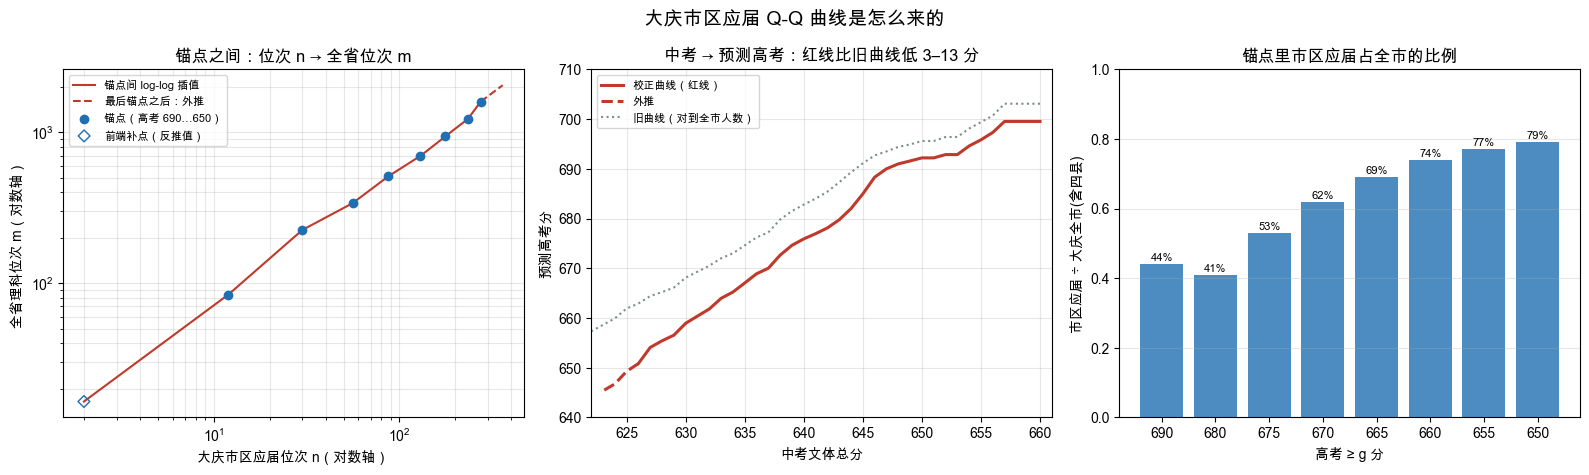

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
BLUE, RED, GREY, ORG = '#1f6fb2', '#c0392b', '#7f8c8d', '#e67e22'

# ① log-log：锚点和插值
a = ax[0]
nn = np.linspace(2, 274, 300)
a.plot(nn, [m_of_n(n) for n in nn], color=RED, label='锚点间 log-log 插值')
nx = np.linspace(274, 360, 40)
a.plot(nx, [ratio * m_old_at(n) for n in nx], '--', color=RED, label='最后锚点之后：外推')
a.scatter([n for n, _ in ANCH[1:]], [m for _, m in ANCH[1:]], color=BLUE, zorder=3, label='锚点（高考 690…650）')
a.scatter([2], [16.4], marker='D', facecolor='none', edgecolor=BLUE, zorder=3, label='前端补点（反推值）')
a.set_xscale('log'); a.set_yscale('log')
a.set_xlabel('大庆市区应届位次 n（对数轴）'); a.set_ylabel('全省理科位次 m（对数轴）')
a.set_title('锚点之间：位次 n → 全省位次 m'); a.legend(fontsize=8); a.grid(alpha=.3, which='both')

# ② 红线 vs 旧曲线
a = ax[1]
body = curve[~curve['外推']]; tail = curve[curve['外推'] | (curve['中考'] == 626)]
a.plot(body['中考'], body['预测高考'], color=RED, lw=2.2, label='校正曲线（红线）')
a.plot(tail['中考'], tail['预测高考'], '--', color=RED, lw=2.2, label='外推')
a.plot(old['中考文体总分'], old['Q-Q预测高考分(一分一段)'], color=GREY, ls=':', label='旧曲线（对到全市人数）')
a.set_xlim(622, 661); a.set_ylim(640, 710)
a.set_xlabel('中考文体总分'); a.set_ylabel('预测高考分')
a.set_title('中考 → 预测高考：红线比旧曲线低 3–13 分'); a.legend(fontsize=8); a.grid(alpha=.3)

# ③ 为什么要校正：市区应届占全市的比例
a = ax[2]
a.bar([str(g) for g in gs], anch['市区应届占全市'], color=BLUE, alpha=.8)
for i, v in enumerate(anch['市区应届占全市']): a.text(i, v + .01, f'{v:.0%}', ha='center', fontsize=8)
a.set_ylim(0, 1)
a.set_xlabel('高考 ≥ g 分'); a.set_ylabel('市区应届 ÷ 大庆全市(含四县)')
a.set_title('锚点里市区应届占全市的比例')
a.grid(alpha=.3, axis='y')

fig.suptitle('大庆市区应届 Q-Q 曲线是怎么来的', fontsize=14)
fig.tight_layout()
fig.savefig('2004年大庆市区应届Q-Q曲线的来源.png', dpi=150)
plt.show()

## 6 这些假设有多敏感？

锚点里最不确定的两个数：**复读比例 10%**、**外县 3 人**。换一个合理范围，看红线会动多少（以中考 640、630 为例）：

In [10]:
def predict_with(z, repeat, out):
    A = [(2, 16.4)] + [(OFFICIAL[g], m_of(g)) if g in OFFICIAL else (n_of(g, repeat, out), m_of(g)) for g in gs]
    A.sort()
    n = city_rank(z); m = m_of_n(n, A)
    return score_of_m(m)

rows = []
for rep, out in [(0.08, 3), (0.10, 3), (0.12, 3), (0.10, 0), (0.10, 6)]:
    rows.append({'复读比例': f'{rep:.0%}', '外县': out, **{f'中考{z}': round(predict_with(z, rep, out), 1) for z in (645, 640, 635, 630)}})
pd.DataFrame(rows).set_index(['复读比例', '外县'])

中考645  中考640  中考635  中考630
复读比例 外县                            
8%   3   685.0  675.8  667.2  659.3
10%  3   685.0  675.8  667.0  658.9
12%  3   685.0  675.7  666.8  658.6
10%  0   685.0  676.1  667.4  659.2
     6   685.0  675.3  666.7  658.7

复读比例在 8%–12%、外县在 0–6 人之间摆动，红线上的预测分只变动 **不到 1 分**（中考 630 分处最多 0.7 分）。相比之下，「用全市人数还是用旧曲线」这个选择造成的差别是 **3–13 分**——说明校正的方向和大小是稳健的，而不是被个别参数左右。

## 7 结论与边界

1. **这条红线是名次对名次的映射**：中考大庆市区第 n 名 → 高考全省第 m 名 → 高考分。它不预测个人，只预测「同一名次的人群」。
2. **锚点只数市区应届**：690、680 分来自官方拆分；675–650 分是估计（复读 10%、外县 3 人），其中 10% 借自鹤岗一中的比例，不是大庆自己的数据。
3. **插值**：锚点之间 log-log 线性。前端（前 12 名）的补点 (2, 16.4) 是我从页面数值反推的，**没有直接的来源资料**。
4. **626 分（市区第 274 名）以下是外推**：来自旧曲线乘一个常数，没有自己的锚点支持，图上画成虚线。
5. **没有计入的因素**：文科、四县县中里的市区外学生、2004 年中考之后转学的学生。这些都会让「同名次的人群」和「市区应届」不完全一致。